# Coursework 2 

## Solar power prediction

0: Recurrent function definitions

1: Data preprocessing and engineering for single-cell and multi-cell prediction

2: Models - The three models used througout the notebook

3: Single cell prediction for UG Hall7 site - 15 minuite time horizon

4: Single cell prediction for UG Hall7 site - 24 hour time horizon

5: Generalised model for multi cell prediction

6: Comparison with naive baseline

In [ ]:
# Importing the relevant libraries

import pandas as pd
import numpy as np
import os
import re
import glob
import difflib
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from concurrent.futures import ThreadPoolExecutor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import optuna
from optuna import visualization as vis
from optuna.trial import TrialState
import seaborn as sns
import json

# Seed for reproducibility

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

## 0

In [ ]:
# Dataloader function
def create_dataloaders(
    df,
    target_col='power(W)',
    exclude_cols=['generation(kWh)'],
    seq_length=48,
    pred_length=1,
    train_end_date='2023-01-01',
    test_end_date='2023-06-01',
    batch_size=64,
    scaler=None,
    shuffle_train=True,
    pin_memory=False,
    num_workers=0
):
    df_copy = df.copy()
    
    if not pd.api.types.is_datetime64_any_dtype(df_copy.index):
        df_copy.index = pd.to_datetime(df_copy.index, format='mixed', dayfirst=True)

    features = [col for col in df_copy.columns if col not in exclude_cols]
    target_idx = features.index(target_col)

    if scaler is None:
        scaler = MinMaxScaler()
        
        # 1. Isolate the training data based on your train_end_date
        train_df = df_copy[df_copy.index < train_end_date]
        
        # 2. FIT the scaler strictly on the training data
        scaler.fit(train_df[features].values)

    # 3. TRANSFORM the entire dataset (DO NOT use fit_transform here!)
    # This applies the Min/Max rules learned from training to the validation/test sets
    scaled_data = scaler.transform(df_copy[features].values)

    xs, ys, indices = [], [], []
    
    # Subtract pred_length so the window doesn't crash into the end of the array
    for i in range(len(scaled_data) - seq_length - pred_length + 1):
        xs.append(scaled_data[i : i + seq_length])
        
        # Take a slice from the target column spanning the next 'pred_length' steps
        ys.append(scaled_data[i + seq_length : i + seq_length + pred_length, target_idx])
        
        # Keep the timestamp corresponding to the start of the prediction
        indices.append(df_copy.index[i + seq_length])

    X, y = np.array(xs), np.array(ys)
    dates = pd.DatetimeIndex(indices)

    t_split = pd.Timestamp(train_end_date)
    v_split = pd.Timestamp(test_end_date)
    
    train_mask = dates < t_split
    test_mask = (dates >= t_split) & (dates < v_split)
    val_mask = dates >= v_split

    def to_tensor(mask):
        return (
            torch.tensor(X[mask], dtype=torch.float32),
            # Because we sliced an array above, y is natively shape (N, pred_length)
            torch.tensor(y[mask], dtype=torch.float32) 
        )

    X_train, y_train = to_tensor(train_mask)
    X_test, y_test = to_tensor(test_mask)
    X_val, y_val = to_tensor(val_mask)

    train_loader = DataLoader(
        TensorDataset(X_train, y_train), 
        batch_size=batch_size, 
        shuffle=shuffle_train, 
        pin_memory=pin_memory, 
        num_workers=num_workers
    )
    
    test_loader = DataLoader(
        TensorDataset(X_test, y_test), 
        batch_size=batch_size, 
        shuffle=False, 
        pin_memory=pin_memory, 
        num_workers=num_workers
    )
    
    val_loader = DataLoader(
        TensorDataset(X_val, y_val), 
        batch_size=batch_size, 
        shuffle=False, 
        pin_memory=pin_memory, 
        num_workers=num_workers
    )

    return train_loader, test_loader, val_loader, scaler, features, target_idx

In [ ]:
# Dataloader function for generalised model 

def create_multicell_dataloaders(
    df,
    cell_id_col='Site_ID',            # <--- NEW: Column name that identifies the cells
    target_col='power(W)',
    exclude_cols=['generation(kWh)'],
    seq_length=48,
    pred_length=1,
    train_end_date='2023-01-01',
    test_end_date='2023-06-01',
    batch_size=64,
    scaler=None,
    shuffle_train=True,
    pin_memory=False,
    num_workers=0
):
    df_copy = df.copy()
    
    # 1. Ensure DateTime index
    if not pd.api.types.is_datetime64_any_dtype(df_copy.index):
        df_copy.index = pd.to_datetime(df_copy.index, format='mixed', dayfirst=True)

    # 2. Select features (exclude the cell ID so we don't accidentally scale it!)
    features = [col for col in df_copy.columns if col not in exclude_cols and col != cell_id_col]
    target_idx = features.index(target_col)

    # 3. LEAKAGE-FREE SCALING
    if scaler is None:
        scaler = MinMaxScaler()
        
        # Isolate training data to fit the scaler
        train_df = df_copy[df_copy.index < train_end_date]
        scaler.fit(train_df[features].values)

    # Transform data and replace the columns IN the dataframe 
    # This keeps the dates and cell_ids attached to the scaled data for the groupby
    df_copy[features] = scaler.transform(df_copy[features].values)

    xs, ys, indices = [], [], []
    
    # 4. GROUP BY CELL TO PREVENT BOUNDARY CROSSING
    for cell_id, group_df in df_copy.groupby(cell_id_col):
        
        # Sort chronologically just in case the raw data rows are mixed up
        group_df = group_df.sort_index() 
        
        # Extract the scaled arrays for this specific cell
        group_data = group_df[features].values
        group_dates = group_df.index
        
        # Build sequences strictly within this cell's timeline
        for i in range(len(group_data) - seq_length - pred_length + 1):
            xs.append(group_data[i : i + seq_length])
            ys.append(group_data[i + seq_length : i + seq_length + pred_length, target_idx])
            indices.append(group_dates[i + seq_length])

    X, y = np.array(xs), np.array(ys)
    dates = pd.DatetimeIndex(indices)

    # 5. SPLIT BY DATE (Masks apply perfectly to the merged sequences)
    t_split = pd.Timestamp(train_end_date)
    v_split = pd.Timestamp(test_end_date)
    
    train_mask = dates < t_split
    test_mask = (dates >= t_split) & (dates < v_split)
    val_mask = dates >= v_split

    def to_tensor(mask):
        return (
            torch.tensor(X[mask], dtype=torch.float32),
            torch.tensor(y[mask], dtype=torch.float32) 
        )

    X_train, y_train = to_tensor(train_mask)
    X_test, y_test = to_tensor(test_mask)
    X_val, y_val = to_tensor(val_mask)

    # 6. CREATE PYTORCH DATALOADERS
    train_loader = DataLoader(
        TensorDataset(X_train, y_train), 
        batch_size=batch_size, 
        shuffle=shuffle_train, 
        pin_memory=pin_memory, 
        num_workers=num_workers
    )
    
    test_loader = DataLoader(
        TensorDataset(X_test, y_test), 
        batch_size=batch_size, 
        shuffle=False, 
        pin_memory=pin_memory, 
        num_workers=num_workers
    )
    
    val_loader = DataLoader(
        TensorDataset(X_val, y_val), 
        batch_size=batch_size, 
        shuffle=False, 
        pin_memory=pin_memory, 
        num_workers=num_workers
    )

    return train_loader, test_loader, val_loader, scaler, features, target_idx

In [ ]:
# Training function

import copy

"""

Cell generated by Gemini 3.1 Pro using prompt:

'I want to combine my training into a single function so that I can train 
multiple models within my notebook without having to rewrite the training script.
I want it to be generalisable though, make it have as many parameters as possible
even though most can be goven default values'

It was further edited by me

"""

def train_model(
    model,
    train_loader,
    test_loader=None,
    val_loader=None,
    fusion_mode = False,
    criterion=None,
    optimizer_class=torch.optim.Adam,
    lr=0.001,
    weight_decay=0.0,
    epochs=50,
    device='cpu',
    patience=5,
    save_best_model=True,
    model_save_path="best_model.pth",
    verbose=1,
    optuna_trial=None
):
    """
    A highly generalized PyTorch training loop for time-series models.
    
    Parameters:
    - model: The PyTorch neural network to train.
    - train_loader: DataLoader for the training set.
    - val_loader: DataLoader for the validation set (used for early stopping).
    - criterion: Loss function (defaults to nn.MSELoss()).
    - optimizer_class: The PyTorch optimizer class (defaults to Adam).
    - lr: Learning rate.
    - weight_decay: L2 regularization penalty (helps prevent overfitting).
    - epochs: Maximum number of epochs to train.
    - device: 'cuda' or 'cpu'. Defaults to auto-detect.
    - patience: Epochs to wait for improvement before Early Stopping (Set to None to disable).
    - save_best_model: Whether to save the weights of the lowest val_loss epoch.
    - model_save_path: Filepath to save the best model weights.
    - gradient_clip: Max norm for gradients (prevents exploding gradients in LSTMs).
    - verbose: How often to print epoch updates (1 = every epoch, 0 = silent).
    - optuna_trial: Pass the `trial` object if running inside an Optuna sweep for pruning.
    
    Returns:
    - model: The trained model (loaded with the best weights if early stopping triggered).
    - history: Dictionary containing lists of 'train_loss' and 'val_loss' over epochs.
    """
    
    # --- 1. Initialization ---
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    model = model.to(device)
    
    if criterion is None:
        criterion = nn.MSELoss()
        
    optimizer = optimizer_class(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {'train_loss': [], 'test_loss': []}
    best_test_loss = float('inf')
    trigger_times = 0

    best_model_weights = copy.deepcopy(model.state_dict())
    
    if verbose > 0:
        print(f"Starting training on {device} for up to {epochs} epochs...")



    # --- 2. Main Epoch Loop ---
    for epoch in range(epochs):
        # 1. Training Phase
        model.train()
        train_loss = 0.0

        if fusion_mode is False:
            for inputs, targets in train_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                loss.backward()
                optimizer.step()
                train_loss += loss.item() * inputs.size(0)
        else:
            for x_dyn, x_stat, targets in train_loader:
                x_dyn, x_stat, targets = x_dyn.to(device), x_stat.to(device), targets.to(device)
                optimizer.zero_grad()
                outputs = model(x_dyn, x_stat)
                loss = criterion(outputs, targets)
                loss.backward()
                optimizer.step()
                train_loss += loss.item() * x_dyn.size(0)

            
        train_loss = train_loss / len(train_loader.dataset)

        eval_metric = nn.L1Loss()
            
        # 2. Testing/Monitoring Phase (Per Epoch)
        model.eval()
        test_loss = 0.0
        with torch.no_grad():

            if fusion_mode is False:
                for inputs, targets in test_loader:
                    inputs, targets = inputs.to(device), targets.to(device)
                    outputs = model(inputs)
                    test_loss += eval_metric(outputs, targets).item() * inputs.size(0)
            else:
                for x_dyn, x_stat, targets in test_loader:
                    x_dyn, x_stat, targets = x_dyn.to(device), x_stat.to(device), targets.to(device)
                    outputs = model(x_dyn, x_stat)
                    test_loss += eval_metric(outputs, targets).item() * x_dyn.size(0)
                
        test_loss = test_loss / len(test_loader.dataset)
        
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)


        # -- Logging --
        if verbose > 0:
            log_msg = f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.6f}"
            if test_loss is not None:
                log_msg += f" | Test Loss: {test_loss:.6f}"
            print(log_msg)
            
        # -- Optuna Pruning --
        if optuna_trial is not None and test_loss is not None:
            optuna_trial.report(test_loss, epoch)
            if optuna_trial.should_prune():
                if verbose > 0:
                    print(f"Trial pruned by Optuna at epoch {epoch+1}")
                raise optuna.TrialPruned()
                
        # -- Early Stopping & Model Checkpointing --
        if test_loss is not None:
            if test_loss < best_test_loss:
                best_test_loss = test_loss
                trigger_times = 0
                if save_best_model:
                    best_model_weights = copy.deepcopy(model.state_dict())
            else:
                trigger_times += 1
                if patience is not None and trigger_times >= patience:
                    if verbose > 0:
                        print(f"Early stopping triggered! No improvement for {patience} epochs.")
                        break

                    

    # --- 3. Finalization ---
    # Load the best weights back into the model before returning it
    if save_best_model and test_loader is not None:
        model.load_state_dict(best_model_weights)
        if verbose > 0:
            print(f"Restored best model weights (Test Loss: {best_test_loss:.6f})")
            
    return model, history


In [ ]:
# Optuna tuning function

def objective(trial, model_name, pred_length=1, fusion_mode=False):
    # --- HYPERPARAMETER SEARCH SPACE ---
    # 1. Architecture
    rnn_type = trial.suggest_categorical("rnn_type", ["GRU"])
    num_layers = trial.suggest_int("num_layers", 1, 3)
    hidden_size = trial.suggest_categorical("hidden_size",[32, 64, 128, 256])

    # PyTorch throws an error if dropout > 0 but num_layers == 1
    dropout = trial.suggest_float("dropout", 0.1, 0.4) if num_layers > 1 else 0.0
    
    # 2. Sequence Length
    seq_length = trial.suggest_categorical("seq_length",[24, 48, 96, 144, 192, 384])
    
    # 3. Learning Rate
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    # Check if fusion mode is on
    # if so a whole different bunch of hyperparams to search for
    if fusion_mode == True:
        fusion_type = trial.suggest_categorical("fusion_type", ["LateFusion", "FiLM"])
        lstm_hidden = trial.suggest_categorical("lstm_hidden", [32, 64, 128, 256])
        if fusion_type == "LateFusion":
            mlp_hidden = trial.suggest_categorical("mlp_hidden",[8, 16, 32, 64])
            model = LateFusionModel(dyn_size, stat_size, lstm_hidden, mlp_hidden, rnn_type, dropout).to(device)
        else:
            model = FiLMModel(dyn_size, stat_size, lstm_hidden, rnn_type, dropout).to(device)
    else:
        model = model_name(INPUT_SIZE, hidden_size, num_layers, rnn_type, dropout).to(device)
 


    # 4. Tune the Training Loss Function
    loss_type = trial.suggest_categorical("loss_type", ["MSE", "MAE", "Huber"])
    if loss_type == "MSE":
        train_criterion = nn.MSELoss()
    elif loss_type == "MAE":
        train_criterion = nn.L1Loss()
    else:
        train_criterion = nn.HuberLoss()
    
    # --- BUILD DATALOADERS DYNAMICALLY ---
    if fusion_mode is False:
        train_dataset = DynamicSequenceDataset(train_scaled, seq_length, target_idx, pred_length)
        test_dataset = DynamicSequenceDataset(test_scaled, seq_length, target_idx, pred_length)
        val_dataset = DynamicSequenceDataset(val_scaled, seq_length, target_idx, pred_length)
    else:
        train_dataset = PVTimeSeriesDataset(train_df, dynamic_cols, static_cols, target_col, sequence_length=seq_length)
        test_dataset = PVTimeSeriesDataset(test_df, dynamic_cols, static_cols, target_col, sequence_length=seq_length)
        val_dataset = PVTimeSeriesDataset(val_df, dynamic_cols, static_cols, target_col, sequence_length=seq_length)


    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
    
    
    # --- TRAIN USING GENERALIZED FUNCTION ---
    trained_model, history = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        val_loader=val_loader, 
        fusion_mode = fusion_mode,
        criterion=train_criterion,
        lr=lr,
        epochs=5,
        device=device,
        patience=2,
        verbose=0, 
        optuna_trial=trial
    )

    # --- FINAL VALIDATION PHASE (Post-Training) ---
    # Evaluate the fully trained model on unseen validation data
    trained_model.eval()
    
    # INDEPENDENT METRIC: Always use MAE to rank the final trial fairly
    eval_criterion = nn.L1Loss() 
    val_loss_sum = 0.0
    
    with torch.no_grad():

        if fusion_mode is False:
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = trained_model(inputs)
                val_loss_sum += eval_criterion(outputs, targets).item() * inputs.size(0)
            
        else:
            for x_dyn, x_stat, targets in val_loader:
                x_dyn, x_stat, targets = x_dyn.to(device), x_stat.to(device), targets.to(device)
                outputs = trained_model(x_dyn, x_stat)
                val_loss_sum += eval_criterion(outputs, targets).item() * x_dyn.size(0) # CHECK THIS - used to be inputs.size(0), not sure if this is equivalent

    final_val_mae = val_loss_sum / len(val_dataset)
    
    # Return the uniform MAE metric back to Optuna
    return final_val_mae

## 1 

Data engineering and preprocessing for single cell prediction

In [ ]:
# Note: for this cell below the run time is really long - can it be improved and made more efficient?
# - answer: i think so, save xl file as a csv then call treat it as a standard csv


# PHASE 1: DATA ENGINEERING & PREPROCESSING
# ==========================================

print("Starting Data Engineering Pipeline...")

# 1. Load and process target data (UG Hall 7)
# Path based on your folder structure
target_path = r"Dataset/Time series dataset/PV generation dataset/PV stations with panel level optimizer/Site level dataset/UG Hall7.csv"

ug_hall = pd.read_csv(target_path, parse_dates=['Time'])
ug_hall = ug_hall[(ug_hall['Time'] >= '2021-01-01') & (ug_hall['Time'] < '2024-01-01')]
ug_hall.set_index('Time', inplace=True)

# Resample target to 15-minute intervals, taking the mean
# (Using '15min' to avoid the Pandas FutureWarning)
ug_hall = ug_hall.resample('15min').mean()

# 2. Define helper function to process weather data from your specific folders
def process_weather_for_year(year):
    base_meteo_path = r"Dataset/Time series dataset/Meteorological dataset"
    
    # Mapping features to their specific folders and files
    files = {
        'Irradiance': os.path.join(base_meteo_path, 'Irradiance', f'Irradiance_{year}.csv'),
        'Relative Humidity': os.path.join(base_meteo_path, 'Relative Humidity', f'Relative Humidity_{year}.csv'),
        'Sea Level Pressure': os.path.join(base_meteo_path, 'Sea Level Pressure', f'Sea Level Pressure_{year}.csv'),
        'Temperature': os.path.join(base_meteo_path, 'Temperature', f'Temperature_{year}.csv'),
        'Visibility': os.path.join(base_meteo_path, 'Visibility', f'Visibility_{year}.csv'),
        'Wind': os.path.join(base_meteo_path, 'Wind', f'Wind_{year}.csv')
    }
    
    # Rainfall has a mix of Excel and CSV formats depending on the year
    if year == 2021:
        files['Rainfall'] = os.path.join(base_meteo_path, 'Rainfall', 'Rainfall_2021.xlsx')
    else:
        files['Rainfall'] = os.path.join(base_meteo_path, 'Rainfall', f'Rainfall_{year}.csv')

    dfs = []
    for feature, filepath in files.items():
        try:
            # Handle the 2021 Excel file anomaly
            if filepath.endswith('.xlsx'):
                df = pd.read_excel(filepath, parse_dates=['Time'])
            else:
                df = pd.read_csv(filepath, parse_dates=['Time'])
                
            df.set_index('Time', inplace=True)
            
            # Convert to numeric, coercing any weird string errors to NaN
            for col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
            
            # Resample: Rainfall needs to be Summed, everything else Averaged
            if feature == 'Rainfall':
                df = df.resample('15min').sum()
            else:
                df = df.resample('15min').mean()
                
            dfs.append(df)
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            
    # Concatenate all weather features for the year into one dataframe
    year_data = pd.concat(dfs, axis=1)
    return year_data

# 3. Process weather for all 3 years
print("Processing weather data for 2021, 2022, and 2023...")
weather_2021 = process_weather_for_year(2021)
weather_2022 = process_weather_for_year(2022)
weather_2023 = process_weather_for_year(2023)

# Combine all years
weather_all = pd.concat([weather_2021, weather_2022, weather_2023], axis=0)

# 4. Merge Weather with Target Power Data
merged_all = pd.concat([ug_hall, weather_all], axis=1)

# Slice cleanly to our exact 3-year window
merged_all = merged_all['2021-01-01':'2023-12-31']

# Drop missing values to maintain sequence continuity for the LSTM
merged_all.dropna(inplace=True)

# 5. Feature Engineering: Cyclical Time Encodings
# Neural networks don't understand that 23:59 is 1 minute away from 00:00.
# We map time to Sine and Cosine waves so the model understands the cyclical nature of days and years.
merged_all['Month'] = merged_all.index.month
merged_all['Hour'] = merged_all.index.hour
merged_all['Minute'] = merged_all.index.minute

time_of_day = merged_all['Hour'] + merged_all['Minute'] / 60.0

merged_all['Month_Sin'] = np.sin(2 * np.pi * merged_all['Month'] / 12)
merged_all['Month_Cos'] = np.cos(2 * np.pi * merged_all['Month'] / 12)
merged_all['Time_Sin'] = np.sin(2 * np.pi * time_of_day / 24)
merged_all['Time_Cos'] = np.cos(2 * np.pi * time_of_day / 24)

# Drop the raw time columns as they are now encoded
merged_all.drop(columns=['Month', 'Hour', 'Minute'], inplace=True)

print(f"\nFinal Phase 1 dataset shape: {merged_all.shape}")
print(f"Columns: {merged_all.columns.tolist()}")

# 6. Save the final processed dataset
output_file = 'UGH7_21_23_merged.csv'
merged_all.to_csv(output_file)
print(f"Successfully saved to '{output_file}'!")

Starting Data Engineering Pipeline...
Processing weather data for 2021, 2022, and 2023...

Final Phase 1 dataset shape: (90012, 14)
Columns: ['generation(kWh)', 'power(W)', 'Irradiance (W/m2)', 'RH (%)', 'SLP (hPa)', 'Temp (Degree Celsius)', 'Vis (km)', 'Wind Speed (m/s)', 'Wind Direction (degree)', 'Rainfall(mm)', 'Month_Sin', 'Month_Cos', 'Time_Sin', 'Time_Cos']
Successfully saved to 'UGH7_21_23_merged.csv'!


Above:

data engineering
* combined all the different variables into one CSV for UGHall7
* full 2021-2023
* resampled power data to 15 mins using mean value, so compatible with the weather
* accounted for xl file for rainfall 
* made time cyclical 
* dropped Nans


Below: 

Data processing for the multi cell prediction

In [ ]:
# importing data for multi cell prediction model
"""

Following cells were produced by Gemini using the prompt:

Write me a cell of code to perform the data engineering required for these models in the most optimal way. make it run as fast as possible. {models were provided also}

"""

# ==========================================
# 1. FAST METADATA EXTRACTION
# ==========================================
print("Extracting metadata...")
with open("Dataset/Metadata/PV generation system metadata.ttl", "r", encoding="utf-8") as file:
    # Read everything as a single massive string, THEN split.
    # This guarantees 'blocks' is a list of strings.
    raw_content = str(file.read()) 
    blocks = raw_content.split("pvsystem:")

# Compile regex for speed
re_num = re.compile(r'ext:number \[ brick:value (\d+)')
re_eff = re.compile(r'ext:ratedModuleConversionEfficiency \[ brick:value ([\d\.]+)')
re_pow = re.compile(r'ext:ratedPowerOutput \[.*?brick:value ([\d\.]+)', re.DOTALL)

metadata_dict = {}

for block in blocks:
    # Ensure block is definitively a string before we do string operations
    block_str = str(block) 
    
    if "a brick:PV_Panel" in block_str:
        # Safely split and grab the first element
        split_block = block_str.split(" ")
        
        if len(split_block) > 0:
            raw_name = str(split_block).strip()
            
            # Extract metrics using walrus operator (Python 3.8+)
            num_panels = float(m.group(1)) if (m := re_num.search(block_str)) else 0.0
            efficiency = float(m.group(1)) if (m := re_eff.search(block_str)) else 0.0
            power_w = float(m.group(1)) if (m := re_pow.search(block_str)) else 0.0
            
            # Safely replace characters
            clean_name = raw_name.replace('__Module', '').replace('__', ' (').replace('_', ' ')
            if '(' in clean_name and ')' not in clean_name:
                clean_name += ')'
                
            metadata_dict[clean_name] = {
                'Num_Panels': num_panels,
                'Efficiency': efficiency,
                'Total_Capacity_W': num_panels * power_w
            }

meta_names = list(metadata_dict.keys())

# ==========================================
# 2. PRE-COMPUTE FUZZY MATCHES & FILE LISTS
# ==========================================
base_path = r"Dataset/Time series dataset/PV generation dataset"
opt_path = os.path.join(base_path, "PV stations with panel level optimizer", "Site level dataset", "*.csv")
no_opt_path = os.path.join(base_path, "PV stations without panel level optimizer", "Site level dataset", "*.csv")

# 1. Grab all file paths
raw_site_files = glob.glob(opt_path) + glob.glob(no_opt_path)

# 2. Define the exact names of the bad sites (these should match the CSV file names)
bad_sites = ['Indoor Sports Centre', 'Zone L2', 'Zone A2', 'UG Hall4 Flexible PV', 'SQ567 Flexible PV', 'SQ Apartment37-38 Flexible PV']

# 3. Filter them out BEFORE doing anything else!
# This checks if any of the bad site strings are inside the file path
all_site_files = [file for file in raw_site_files if not any(bad in file for bad in bad_sites)]

# Do fuzzy matching once upfront
site_match_map = {}
for file in all_site_files:
    site_name = os.path.basename(file).replace('.csv', '')
    matches = difflib.get_close_matches(site_name, meta_names, n=1, cutoff=0.4)
    has_optimizer = 1 if "with panel level optimizer" in file and "without" not in file else 0
    
    if matches:
        meta = metadata_dict[matches]
        site_match_map[file] = (site_name, has_optimizer, meta['Total_Capacity_W'], meta['Efficiency'])
    else:
        site_match_map[file] = (site_name, has_optimizer, 0.0, 0.0)

# ==========================================
# 3. MULTI-THREADED DATA LOADING & MERGING
# ==========================================
print("Loading weather data...")
weather_df = pd.read_csv('Dataset/Time series dataset/merged_data_2021_to_2023_full.csv')
# Optimized datetime parsing
weather_df['Time'] = pd.to_datetime(weather_df['Time'], format='mixed', dayfirst=True)
weather_df.set_index('Time', inplace=True)
weather_df = weather_df.drop(columns=['generation(kWh)', 'power(W)'], errors='ignore')

def process_site(file):
    site_name, has_opt, cap, eff = site_match_map[file]
    try:
        # engine='pyarrow' is significantly faster if installed (pip install pyarrow)
        df = pd.read_csv(file, engine='python') 
        df['Time'] = pd.to_datetime(df['Time'])
        df.set_index('Time', inplace=True)
        
        # Resample and drop NaNs early to save memory
        df = df.resample('15min').mean().dropna()
        
        # Add static features
        df['Has_Optimizer'] = has_opt
        df['Total_Capacity_W'] = cap
        df['Efficiency'] = eff
        df['Site_ID'] = site_name
        return df
    except Exception as e:
        print(f"Error on {site_name}: {e}")
        return None

print("Processing site data in parallel...")
# Use ThreadPool for I/O bound tasks (reading CSVs)
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    results = list(executor.map(process_site, all_site_files))

# Filter out failed reads and concatenate
all_sites_data = [res for res in results if res is not None]
mega_dataset = pd.concat(all_sites_data, axis=0)

# Single massive join is faster than joining inside the loop
mega_dataset = mega_dataset.join(weather_df, how='inner').dropna()
print(f"Mega-Dataset complete! Total rows: {len(mega_dataset)}")



In [ ]:
# Data cleansing
# Assuming mega_dataset index is already your Datetime object

print(f"Original size: {len(mega_dataset)}")

# 1. Extract just the date (ignoring the time)
mega_dataset['Date'] = mega_dataset.index.date

# 2. Calculate the maximum power generated by each site on each specific day
# transform('max') maps that daily maximum back to every 15-minute row for that day
daily_max_power = mega_dataset.groupby(['Site_ID', 'Date'])['power(W)'].transform('max')

# 3. Filter the dataset. 
# We use > 5 Watts instead of > 0 to account for tiny electrical sensor noise during dead weeks.
clean_mega_dataset = mega_dataset[daily_max_power > 5].copy()

# Drop the temporary Date column
clean_mega_dataset = clean_mega_dataset.drop(columns=['Date'])

print(f"Cleaned size: {len(clean_mega_dataset)} (Removed {len(mega_dataset) - len(clean_mega_dataset)} dead rows)")

# Proceed with splitting using clean_mega_dataset instead of mega_dataset!

In [ ]:
# 4. ALIGNING FOR LATE FUSION / FiLM MODELS
# ==========================================
# Separate features
target_col = 'power(W)' 
static_cols = ['Has_Optimizer', 'Total_Capacity_W', 'Efficiency']

# 1. Force pandas to only look at numeric columns (floats and ints)
numeric_columns = mega_dataset.select_dtypes(include=['number']).columns

# 2. Build dynamic_cols strictly from those numeric columns
dynamic_cols = [c for c in numeric_columns if c not in static_cols + [target_col]]


# 1. Define the exact Site IDs you want to hold out for testing. 
# (Replace these strings with actual names from your mega_dataset['Site_ID'])
holdout_sites = ['Zone A4', 'SQ Block R', 'UG Hall7 Flexible PV'] 

# 2. Create the masks
# Test set: ONLY the 3 holdout sites (we can give them their entire timeline to test on)
test_mask = mega_dataset['Site_ID'].isin(holdout_sites)

# Train & Val sets: ONLY the remaining sites, split chronologically
train_mask = (~test_mask) & (mega_dataset.index <= '2021-06-30')
val_mask = (~test_mask) & (mega_dataset.index >= '2021-07-01') & (mega_dataset.index <= '2021-09-30')

# 3. Create the DataFrames
train_df = mega_dataset.loc[train_mask].copy()
val_df = mega_dataset.loc[val_mask].copy()
test_df = mega_dataset.loc[test_mask].copy()

# 4. FIT SCALERS ON TRAIN ONLY (Crucial for Spatial Generalization)
dyn_scaler = StandardScaler().fit(train_df[dynamic_cols])
stat_scaler = StandardScaler().fit(train_df[static_cols])
target_scaler = StandardScaler().fit(train_df[[target_col]])

# 5. TRANSFORM ALL
for df in [train_df, val_df, test_df]:
    df[dynamic_cols] = dyn_scaler.transform(df[dynamic_cols])
    df[static_cols] = stat_scaler.transform(df[static_cols])
    df[[target_col]] = target_scaler.transform(df[[target_col]])

## 2

Machine learning models used throughout the notebook

In [ ]:
# Flexible RNN Model (Can be LSTM or GRU)
# For single cell prediction

class FlexibleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, rnn_type, dropout):
        super(FlexibleRNN, self).__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.rnn_type = rnn_type
        
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        else:
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
            
        self.fc = nn.Linear(hidden_size, 1) # Sequence-to-One
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        if self.rnn_type == 'LSTM':
            c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
            out, _ = self.rnn(x, (h0, c0))
        else:
            # GRU does not have a cell state (c0)
            out, _ = self.rnn(x, h0)
            
        out = self.fc(out[:, -1, :])
        return out

In [ ]:
# Flexible RNN Model for Multi-Step Prediction (Can be LSTM or GRU)
# For single cell prediction

class FlexibleMultiStepRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, rnn_type, dropout):
        super(FlexibleMultiStepRNN, self).__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.rnn_type = rnn_type
        
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        else:
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
            
        self.fc = nn.Linear(hidden_size, future_steps) # Sequence-to-One
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        if self.rnn_type == 'LSTM':
            c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
            out, _ = self.rnn(x, (h0, c0))
        else:
            # GRU does not have a cell state (c0)
            out, _ = self.rnn(x, h0)
            
        out = self.fc(out[:, -1, :])
        return out

In [ ]:
# Late Fusion model

class LateFusionModel(nn.Module):
    def __init__(self, dyn_input_size, stat_input_size, lstm_hidden, mlp_hidden, rnn_type='GRU', dropout=0.2):
        super().__init__()
        
        # 1. Dynamic Branch
        self.rnn = getattr(nn, rnn_type)(dyn_input_size, lstm_hidden, num_layers=2, batch_first=True, dropout=dropout)
        
        # 2. Static Branch
        self.static_mlp = nn.Sequential(
            nn.Linear(stat_input_size, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # 3. Fusion Head
        self.fusion_head = nn.Sequential(
            nn.Linear(lstm_hidden + mlp_hidden, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x_dyn, x_stat):
        rnn_out, _ = self.rnn(x_dyn)
        h_dyn = rnn_out[:, -1, :]  # Grab final hidden state
        h_stat = self.static_mlp(x_stat)
        
        # Concatenate and predict
        combined = torch.cat((h_dyn, h_stat), dim=1)
        return self.fusion_head(combined)

In [ ]:
# FiLM model

class FiLMModel(nn.Module):
    def __init__(self, dyn_input_size, stat_input_size, lstm_hidden, rnn_type='GRU', dropout=0.2):
        super().__init__()
        
        # 1. Dynamic Branch
        self.rnn = getattr(nn, rnn_type)(dyn_input_size, lstm_hidden, num_layers=2, batch_first=True, dropout=dropout)
        
        # 2. FiLM Generator (Calculates Gamma and Beta from Static Data)
        # It must output a vector 2x the size of lstm_hidden (one half for gamma, one half for beta)
        self.film_generator = nn.Sequential(
            nn.Linear(stat_input_size, 32),
            nn.ReLU(),
            nn.Linear(32, lstm_hidden * 2) 
        )
        
        # Initialize the final layer of the generator to zero (Crucial for stability!)
        nn.init.zeros_(self.film_generator[-1].weight)
        nn.init.zeros_(self.film_generator[-1].bias)
        
        # 3. Final Prediction Head
        self.prediction_head = nn.Linear(lstm_hidden, 1)

    def forward(self, x_dyn, x_stat):
        rnn_out, _ = self.rnn(x_dyn)
        h_dyn = rnn_out[:, -1, :]  # Shape: (batch_size, lstm_hidden)
        
        # Generate FiLM parameters
        film_params = self.film_generator(x_stat)
        
        # Split into Gamma and Beta
        # Gamma gets +1 so the default scaling is 1.0 (identity) before learning
        gamma = film_params[:, :h_dyn.size(1)] + 1.0 
        beta = film_params[:, h_dyn.size(1):]
        
        # Apply the FiLM Affine Transformation
        modulated_h = (gamma * h_dyn) + beta
        
        # Predict based on modulated features
        return self.prediction_head(modulated_h)

## 3

Single cell prediction - 15 minuite time horizon for UG Hal 7

In [177]:
# Load data for optuna

print("Loading data...")
df = merged_all.copy()
df.index = pd.to_datetime(df.index, format='mixed', dayfirst=True)

# Select features
features = [col for col in df.columns if col != 'generation(kWh)']
target_col = 'power(W)'
target_idx = features.index(target_col)

# Train/Val Split (Train on 2021 to 2022, Validate on early-2022, test on later-2022)
train_df = df.loc['2021-06-01':'2021-12-31']
test_df = df.loc['2022-01-01':'2022-03-31']
val_df = df.loc['2022-03-01':'2022-06-30']


# Scale
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df[features].values).astype(np.float32)
val_scaled = scaler.transform(val_df[features].values).astype(np.float32)
test_scaled = scaler.transform(test_df[features].values).astype(np.float32)

print('Done :)')

Loading data...
Done :)


In [178]:
class DynamicSequenceDataset(Dataset):
    def __init__(self, data, seq_length, target_idx, pred_length=1):
    
        self.data = data
        self.seq_length = seq_length
        self.target_idx = target_idx
        self.pred_length = pred_length

    def __len__(self):
        return len(self.data) - self.seq_length - self.pred_length + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_length]
        start_y = idx + self.seq_length
        end_y = start_y + self.pred_length
        y = self.data[start_y : end_y, self.target_idx]
        return torch.tensor(x), torch.tensor(y)


In [ ]:
# 4. Optuna Objective Function
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
INPUT_SIZE = len(features)



NOTE: 

Below is using optuna tree-structured parzen estimator - bayesian optimisation 

very efficient and very good - far better than grid search

utilises harsher pruning too - uses a tournerment style pruning where it starts 9 at once and then kills off the bottom 
2/3 after a bit and so on

also uses a smaller training size for optuna - 1 year of data not 2+

In [134]:
# HYPERPARAMETER TUNING TOGGLE
# ==========================================

# Run optimisation: ON!
RUN_OPTUNA_SWEEP = True

if RUN_OPTUNA_SWEEP:
    print("Initiating Optuna Hyperparameter Sweep...")
    
    # We use a deterministic seed so the marker gets the exact same results if they do run it
    sampler = optuna.samplers.TPESampler(seed=42)
    study = optuna.create_study(direction="minimize", sampler=sampler, pruner=optuna.pruners.HyperbandPruner(min_resource=2, reduction_factor=3))

    # Run for a specified number of trials
    study.optimize(lambda trial: objective(trial, model_name=FlexibleRNN), n_trials=1)
    
    print("\n--- OPTIMIZATION COMPLETE ---")
    print("Best Trial Value (MAE):", study.best_value)
    print("Best Parameters:")
    
    # This prints a dictionary you can literally copy and paste into the 'else' block
    best_params = study.best_params
    print(json.dumps(best_params, indent=4))

else:
    print("Skipping multi-hour Optuna sweep.")
    print("Loading pre-computed optimal hyperparameters to save compute time...")
    
    # REPLACE THIS DICTIONARY with the output printed from your actual run!
    best_params ={
    "rnn_type": "GRU",
    "num_layers": 2,
    "hidden_size": 256,
    "dropout": 0.16888425598753937,
    "seq_length": 192,
    "lr": 0.006414357128962225,
    "loss_type": "MAE"}

print("\nActive Hyperparameters for Final Training:")
for key, value in best_params.items():
    print(f" - {key}: {value}")

[I 2026-04-19 10:59:51,873] A new study created in memory with name: no-name-f2e3eb86-9eb4-4463-9666-c599874b4f5d


Initiating Optuna Hyperparameter Sweep...


[I 2026-04-19 11:08:02,674] Trial 0 finished with value: 0.033117383975737595 and parameters: {'rnn_type': 'GRU', 'num_layers': 3, 'hidden_size': 32, 'dropout': 0.3598528437324806, 'seq_length': 144, 'lr': 0.0002310201887845295, 'loss_type': 'Huber'}. Best is trial 0 with value: 0.033117383975737595.



--- OPTIMIZATION COMPLETE ---
Best Trial Value (MAE): 0.033117383975737595
Best Parameters:
{
    "rnn_type": "GRU",
    "num_layers": 3,
    "hidden_size": 32,
    "dropout": 0.3598528437324806,
    "seq_length": 144,
    "lr": 0.0002310201887845295,
    "loss_type": "Huber"
}

Active Hyperparameters for Final Training:
 - rnn_type: GRU
 - num_layers: 3
 - hidden_size: 32
 - dropout: 0.3598528437324806
 - seq_length: 144
 - lr: 0.0002310201887845295
 - loss_type: Huber


In [135]:
fig_history = vis.plot_optimization_history(study)
fig_history.show()

fig_importances = vis.plot_param_importances(study)
fig_importances.show()

ValueError: Cannot evaluate parameter importances with only a single trial.

In [136]:
# Calling dataloader function
train_loader, test_loader, val_loader, scaler, features, target_idx = create_dataloaders(
    df=merged_all,
    seq_length=best_params['seq_length'],
    batch_size=64
)

Starting training on cpu for up to 1 epochs...
Epoch [1/1] | Train Loss: 0.006745 | Test Loss: 0.040942
Restored best model weights (Test Loss: 0.040942)


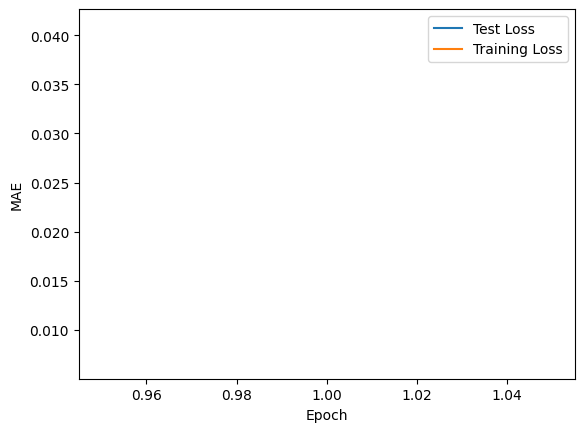

In [137]:
input_size = len(features)

if best_params['loss_type'] == 'MSE':
    criterion = nn.MSELoss()
elif best_params['loss_type'] == 'L1loss':
    criterion = nn.L1Loss()
else:
    criterion = nn.HuberLoss()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FlexibleRNN(input_size, best_params['hidden_size'], best_params['num_layers'], best_params['rnn_type'], best_params['dropout']).to(device)
num_epochs = 1

model, history = train_model(model = model, train_loader= train_loader, test_loader= test_loader, val_loader= val_loader, criterion= criterion, lr = best_params['lr'], epochs = num_epochs)

plt.plot(range(1, len(history['test_loss'])+1), history['test_loss'], label = 'Test Loss')
plt.plot(range(1, len(history['train_loss'])+1), history['train_loss'], label = 'Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()


Above:

Model and training
* Defines an RNN with LSTM - learn more detail about the architecture 
* trains the model and plots the losses


Average Validation MSE: 0.005076
Average Validation NMAE: 12.14%


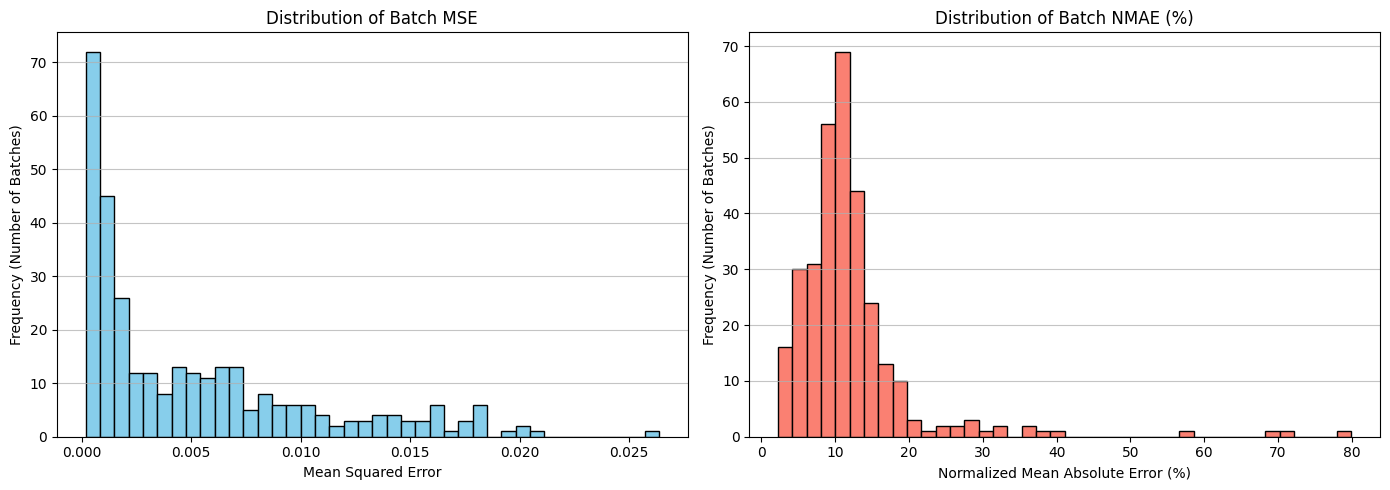

In [138]:
# 8. Final validation evaluation - of unoptimised model
# ==========================================

model.eval()
val_mse_list = []
val_nmae_list = []

with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(val_loader, start=1):
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)

        # MSE in scaled space
        batch_mse = criterion(outputs, targets).item()
        val_mse_list.append(batch_mse)

        # NMAE in original power units (Watts)
        preds_batch = outputs.cpu().numpy().flatten()
        actuals_batch = targets.cpu().numpy().flatten()

        dummy_preds = np.zeros((len(preds_batch), len(features)))
        dummy_actuals = np.zeros((len(actuals_batch), len(features)))
        dummy_preds[:, target_idx] = preds_batch
        dummy_actuals[:, target_idx] = actuals_batch

        preds_unscaled = scaler.inverse_transform(dummy_preds)[:, target_idx]
        actuals_unscaled = scaler.inverse_transform(dummy_actuals)[:, target_idx]
        preds_unscaled = np.maximum(preds_unscaled, 0)

        batch_mae = np.mean(np.abs(actuals_unscaled - preds_unscaled))
        batch_peak = np.max(actuals_unscaled)

        if batch_peak > 0:
            batch_nmae = (batch_mae / batch_peak) * 100
        else:
            batch_nmae = np.nan

        val_nmae_list.append(batch_nmae)
        
        # ---> REMOVED the per-batch print statement here <---

# Calculate averages
avg_val_mse = float(np.nanmean(val_mse_list))
avg_val_nmae = float(np.nanmean(val_nmae_list))

# Print only the final averages
print(f"\nAverage Validation MSE: {avg_val_mse:.6f}")
print(f"Average Validation NMAE: {avg_val_nmae:.2f}%")

# ==========================================
# Plotting the Error Histograms
# ==========================================

# Filter out any NaN values from NMAE list so matplotlib doesn't complain
clean_nmae_list = [x for x in val_nmae_list if not np.isnan(x)]

# Create a figure with two subplots side-by-side
plt.figure(figsize=(14, 5))

# Plot 1: Histogram for MSE
plt.subplot(1, 2, 1)
plt.hist(val_mse_list, bins=40, color='skyblue', edgecolor='black')
plt.title('Distribution of Batch MSE')
plt.xlabel('Mean Squared Error')
plt.ylabel('Frequency (Number of Batches)')
plt.grid(axis='y', alpha=0.75)

# Plot 2: Histogram for NMAE
plt.subplot(1, 2, 2)
plt.hist(clean_nmae_list, bins=40, color='salmon', edgecolor='black')
plt.title('Distribution of Batch NMAE (%)')
plt.xlabel('Normalized Mean Absolute Error (%)')
plt.ylabel('Frequency (Number of Batches)')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

Above:

Tests the model on the validation data
* returns the MSE and NMAE for each batch aswell as the whole validation set
* 7.9% seems decent but hard to say for sure

going to need to adapt this - this is validating it on the 2023 data but its already seen it all 

Average Percentage Deviation (MAPE - Daylight hours only): 290.25%
Mean Absolute Error (MAE - All hours): 991.58 Watts
Normalised Mean Absolute Error (NMAE - All hours): 3.97


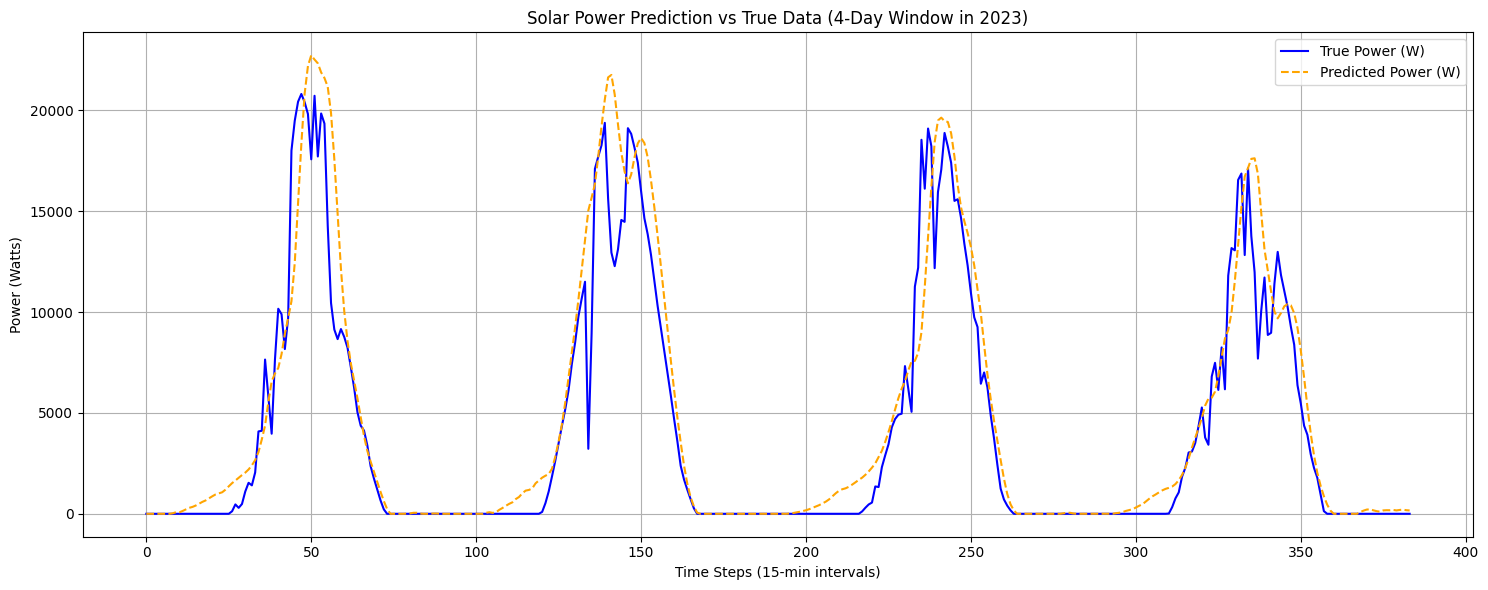

In [139]:
# Plot as a few days - good visualisation - little misleading
# 1. Gather Predictions and Actuals from the 2023 Test Set
model.eval()
all_preds = []
all_actuals = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        
        # Move back to CPU and convert to numpy
        all_preds.append(outputs.cpu().numpy())
        all_actuals.append(targets.cpu().numpy())

# Flatten lists
preds_array = np.concatenate(all_preds).flatten()
actuals_array = np.concatenate(all_actuals).flatten()

# 2. Inverse Transform to Original Scale (Watts)
# Create dummy arrays matching the exact number of features used during scaling
num_features = len(features)
dummy_preds = np.zeros((len(preds_array), num_features))
dummy_actuals = np.zeros((len(actuals_array), num_features))

# Place the predictions/actuals into the correct target column index
dummy_preds[:, target_idx] = preds_array
dummy_actuals[:, target_idx] = actuals_array

# Inverse transform and extract just the target column
preds_unscaled = scaler.inverse_transform(dummy_preds)[:, target_idx]
actuals_unscaled = scaler.inverse_transform(dummy_actuals)[:, target_idx]

# Ensure no negative predictions (solar power cannot physically be negative)
preds_unscaled = np.maximum(preds_unscaled, 0)

# 3. Calculate Validation Metrics
# Filter out nighttime / zero-power data to avoid Division by Zero
daylight_mask = actuals_unscaled > 1.0

if np.sum(daylight_mask) > 0:
    mape = np.mean(np.abs((actuals_unscaled[daylight_mask] - preds_unscaled[daylight_mask]) / actuals_unscaled[daylight_mask])) * 100
    print(f"Average Percentage Deviation (MAPE - Daylight hours only): {mape:.2f}%")
else:
    print("Not enough daylight data to calculate meaningful percentage deviation.")

mae = np.mean(np.abs(actuals_unscaled - preds_unscaled))
nmae = (mae / actuals_unscaled.max()) * 100
print(f"Mean Absolute Error (MAE - All hours): {mae:.2f} Watts")
print(f"Normalised Mean Absolute Error (NMAE - All hours): {nmae:.2f}")

# 4. Visualization (Plotting a 4-day window)
# 96 steps per day. Let's start at index 96 * 100 (approx 100 days into 2023, mid-April) 
# to see some good spring/summer generation curves.
START_IDX = 96 * 100
PLOT_WINDOW = 96 * 4  # 4 days

# Safely handle if the test set is shorter than expected
if START_IDX + PLOT_WINDOW > len(actuals_unscaled):
    START_IDX = 0

plt.figure(figsize=(15, 6))
plt.plot(actuals_unscaled[START_IDX : START_IDX + PLOT_WINDOW], label='True Power (W)', color='blue', linewidth=1.5)
plt.plot(preds_unscaled[START_IDX : START_IDX + PLOT_WINDOW], label='Predicted Power (W)', color='orange', linestyle='--', linewidth=1.5)

plt.title('Solar Power Prediction vs True Data (4-Day Window in 2023)')
plt.xlabel('Time Steps (15-min intervals)')
plt.ylabel('Power (Watts)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Above:

I believe this just applies the model to a significant chunk of data and then visualises it

visualisation plot is a little misleading as the model is only acutally predicting the next 15 minuite interval

I think this experiences data leakage from the training and visualisation above. check it hasnt already seen this validation data.

Good NMAE, worryingly though its a lot better than higher up, data leakage? 

In [140]:

residuals = actuals_unscaled - preds_unscaled

np.shape(residuals)

(14493,)

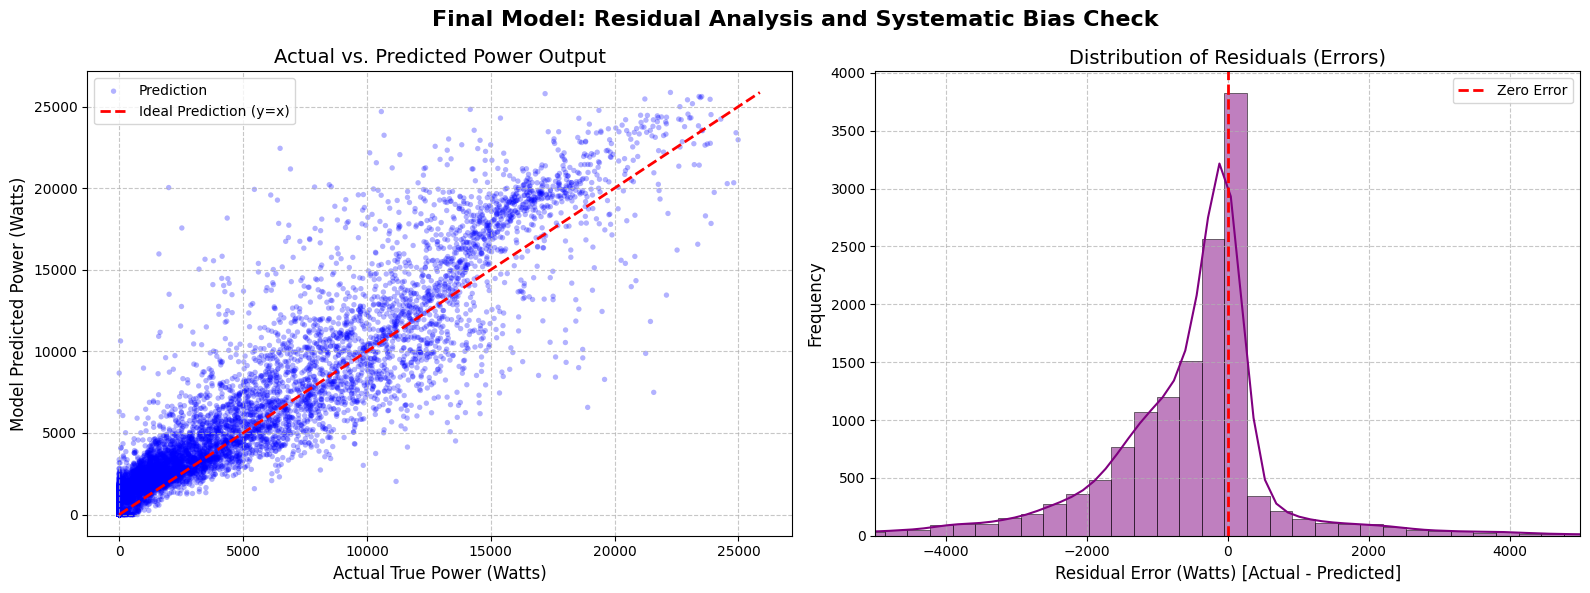

In [141]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Residuals
residuals = actuals_unscaled - preds_unscaled

# Set up the figure for side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Actual vs. Predicted Scatter Plot ---
# FIX: Removed to plot the entire arrays
axes[0].scatter(actuals_unscaled, preds_unscaled, alpha=0.3, color='blue', edgecolor='none', s=15, label = 'Prediction')

# Plot the "Perfect Accuracy" line (y = x)
max_val = max(np.max(actuals_unscaled), np.max(preds_unscaled))
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideal Prediction (y=x)')

axes[0].set_title('Actual vs. Predicted Power Output', fontsize=14)
axes[0].set_xlabel('Actual True Power (Watts)', fontsize=12)
axes[0].set_ylabel('Model Predicted Power (Watts)', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Residuals Distribution Histogram ---
# FIX 1: Removed from residuals so seaborn gets the whole array
# FIX 2: Changed ax=axes to ax=axes so it plots on the right subplot
sns.histplot(residuals, bins=100, kde=True, ax=axes[1], color='purple', edgecolor='black')

axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].set_title('Distribution of Residuals (Errors)', fontsize=14)
axes[1].set_xlabel('Residual Error (Watts) [Actual - Predicted]', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_xlim(-5000, 5000)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Final Model: Residual Analysis and Systematic Bias Check', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Next - model optimisation and LSTM v GRU testing

Want to test LSTM v GRU to prove which is best

For each I want to optimise all the hyperparameters:
* hidden size
* layers
* learning rate
* weight decay?
* optimiser?
* sequence length

going to use optuna and create a variable dataloader

## 4

single cell prediction - 24 hours time horizon for UG Hall7


In [142]:
# How many 15 min intervals to predict forwards
future_steps = 96


In [144]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_size = len(features)


RUN_OPTUNA_SWEEP = True

if RUN_OPTUNA_SWEEP:
    print("Initiating Optuna Hyperparameter Sweep...")
    
    # We use a deterministic seed so the marker gets the exact same results if they do run it
    sampler = optuna.samplers.TPESampler(seed=42)
    study = optuna.create_study(direction="minimize", sampler=sampler, pruner=optuna.pruners.HyperbandPruner(min_resource=2, reduction_factor=3))

    # Run for a specified number of trials
    study.optimize(lambda trial: objective(trial, model_name=FlexibleMultiStepRNN, pred_length=future_steps), n_trials=1)
    
    print("\n--- OPTIMIZATION COMPLETE ---")
    print("Best Trial Value (MAE):", study.best_value)
    print("Best Parameters:")
    
    # This prints a dictionary you can literally copy and paste into the 'else' block
    best_params = study.best_params
    print(json.dumps(best_params, indent=4))

else:
    print("Skipping multi-hour Optuna sweep.")
    print("Loading pre-computed optimal hyperparameters to save compute time...")
    
    # REPLACE THIS DICTIONARY with the output printed from your actual run!
    best_params = {
        "rnn_type": "GRU",
        "num_layers": 3,
        "hidden_size": 32,
        "dropout": 0.3598528437324806,
        "seq_length": 144,
        "lr": 0.0002310201887845295,
        "loss_type": "Huber"
    }


[I 2026-04-19 11:11:54,677] A new study created in memory with name: no-name-00214a5f-3a98-43cb-896a-05bbde2afc13


Initiating Optuna Hyperparameter Sweep...


[I 2026-04-19 11:18:56,675] Trial 0 finished with value: 0.06903124016907128 and parameters: {'rnn_type': 'GRU', 'num_layers': 3, 'hidden_size': 32, 'dropout': 0.3598528437324806, 'seq_length': 144, 'lr': 0.0002310201887845295, 'loss_type': 'Huber'}. Best is trial 0 with value: 0.06903124016907128.



--- OPTIMIZATION COMPLETE ---
Best Trial Value (MAE): 0.06903124016907128
Best Parameters:
{
    "rnn_type": "GRU",
    "num_layers": 3,
    "hidden_size": 32,
    "dropout": 0.3598528437324806,
    "seq_length": 144,
    "lr": 0.0002310201887845295,
    "loss_type": "Huber"
}


In [145]:
fig_history = vis.plot_optimization_history(study)
fig_history.show()

fig_importances = vis.plot_param_importances(study)
fig_importances.show()

ValueError: Cannot evaluate parameter importances with only a single trial.

In [146]:
# Calling dataloader function
train_loader, test_loader, val_loader, scaler, features, target_idx = create_dataloaders(
    df=merged_all,
    seq_length=best_params['seq_length'],
    pred_length = future_steps,
    batch_size=64
)

Starting training on cpu for up to 1 epochs...
Epoch [1/1] | Train Loss: 0.015746 | Test Loss: 0.075437
Restored best model weights (Test Loss: 0.075437)


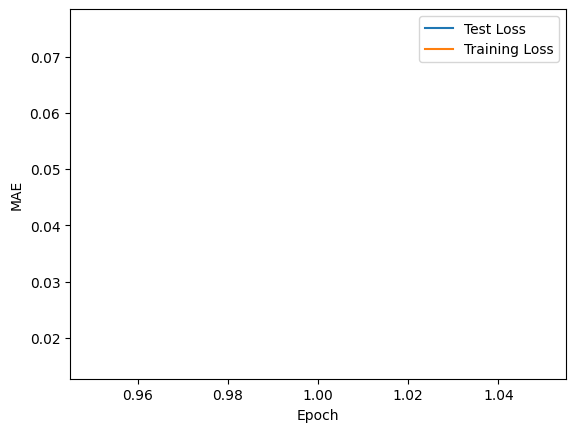

In [147]:
input_size = len(features)

if best_params['num_layers'] == 1:
    dropout = 0
else:
    dropout = best_params['dropout']

if best_params['loss_type'] == 'MSE':
    criterion = nn.MSELoss()
elif best_params['loss_type'] == 'L1loss':
    criterion = nn.L1Loss()
else:
    criterion = nn.HuberLoss()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FlexibleMultiStepRNN(input_size, best_params['hidden_size'], best_params['num_layers'], best_params['rnn_type'], dropout).to(device)
num_epochs = 1

model, history = train_model(model = model, train_loader= train_loader, test_loader= test_loader, val_loader= val_loader, criterion= criterion, lr = best_params['lr'], epochs = num_epochs)

plt.plot(range(1, len(history['test_loss'])+1), history['test_loss'], label = 'Test Loss')
plt.plot(range(1, len(history['train_loss'])+1), history['train_loss'], label = 'Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()



Average Validation MSE: 0.005410
Average Validation NMAE: 10.73%


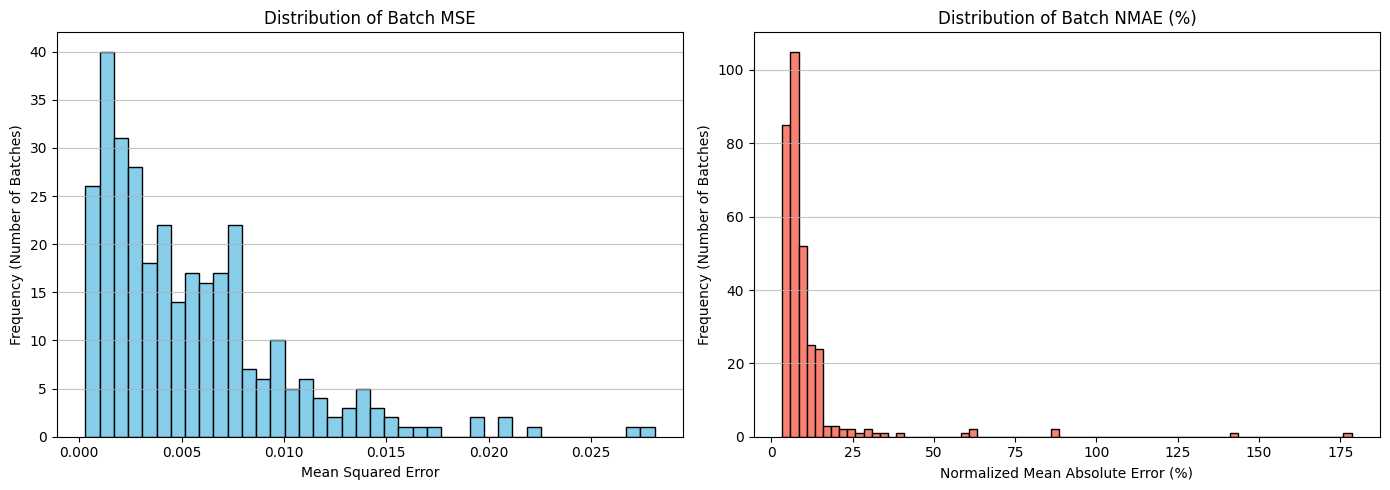

In [ ]:
# 8. Final validation evaluation - of unoptimised model
# ==========================================

model.eval()
val_mse_list = []
val_nmae_list = []

with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(val_loader, start=1):
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)

        # MSE in scaled space
        batch_mse = criterion(outputs, targets).item()
        val_mse_list.append(batch_mse)

        # NMAE in original power units (Watts)
        preds_batch = outputs.cpu().numpy().flatten()
        actuals_batch = targets.cpu().numpy().flatten()

        dummy_preds = np.zeros((len(preds_batch), len(features)))
        dummy_actuals = np.zeros((len(actuals_batch), len(features)))
        dummy_preds[:, target_idx] = preds_batch
        dummy_actuals[:, target_idx] = actuals_batch

        preds_unscaled = scaler.inverse_transform(dummy_preds)[:, target_idx]
        actuals_unscaled = scaler.inverse_transform(dummy_actuals)[:, target_idx]
        preds_unscaled = np.maximum(preds_unscaled, 0)

        batch_mae = np.mean(np.abs(actuals_unscaled - preds_unscaled))
        batch_peak = np.max(actuals_unscaled)

        if batch_peak > 0:
            batch_nmae = (batch_mae / batch_peak) * 100
        else:
            batch_nmae = np.nan

        val_nmae_list.append(batch_nmae)
        
        # ---> REMOVED the per-batch print statement here <---

# Calculate averages
avg_val_mse = float(np.nanmean(val_mse_list))
avg_val_nmae = float(np.nanmean(val_nmae_list))

# Print only the final averages
print(f"\nAverage Validation MSE: {avg_val_mse:.6f}")
print(f"Average Validation NMAE: {avg_val_nmae:.2f}%")

# ==========================================
# Plotting the Error Histograms
# ==========================================

# Filter out any NaN values from NMAE list so matplotlib doesn't complain
clean_nmae_list = [x for x in val_nmae_list if not np.isnan(x)]

# Create a figure with two subplots side-by-side
plt.figure(figsize=(14, 5))

# Plot 1: Histogram for MSE
plt.subplot(1, 2, 1)
plt.hist(val_mse_list, bins=40, color='skyblue', edgecolor='black')
plt.title('Distribution of Batch MSE')
plt.xlabel('Mean Squared Error')
plt.ylabel('Frequency (Number of Batches)')
plt.grid(axis='y', alpha=0.75)

# Plot 2: Histogram for NMAE
plt.subplot(1, 2, 2)
plt.hist(clean_nmae_list, bins=70, color='salmon', edgecolor='black')
plt.title('Distribution of Batch NMAE (%)')
plt.xlabel('Normalized Mean Absolute Error (%)')
plt.ylabel('Frequency (Number of Batches)')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

Average Percentage Deviation (MAPE - Daylight hours only): 312.91%
Mean Absolute Error (MAE - All hours): 1222.39 Watts
Normalised Mean Absolute Error (NMAE - All hours): 4.89%


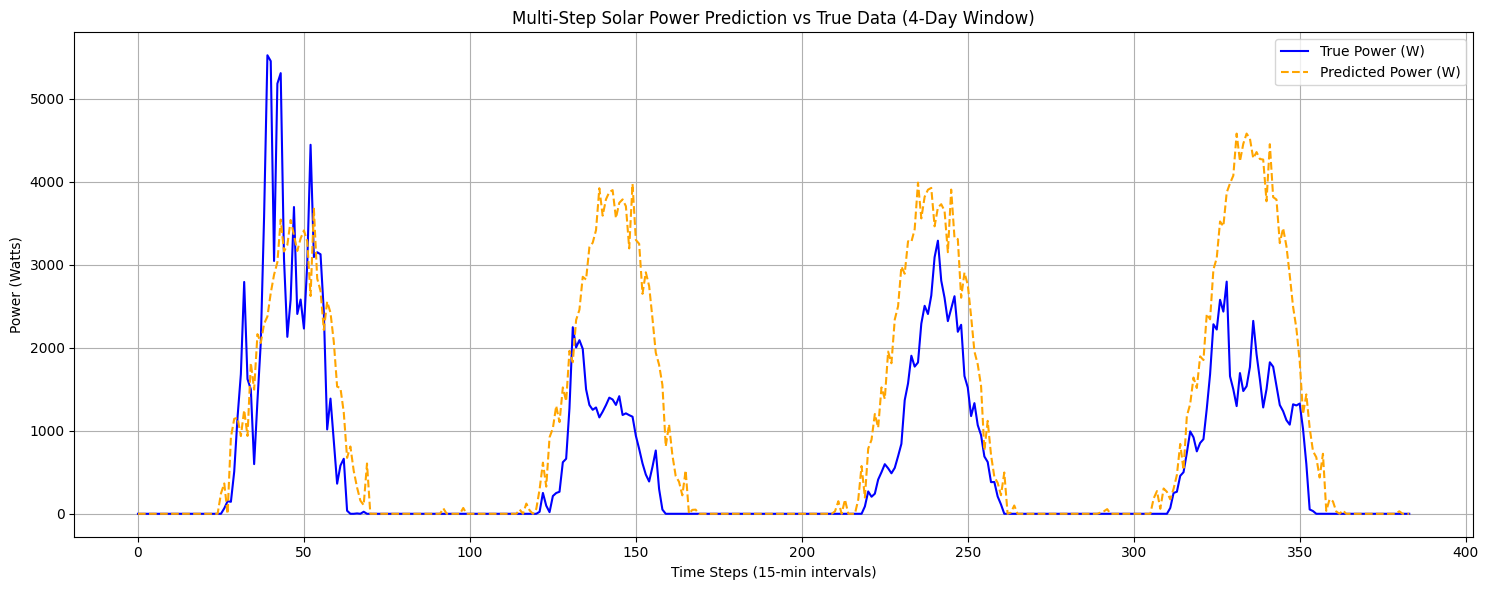

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Define your prediction length (12 hours * 4 steps/hour = 48)
PRED_LENGTH = 96 

# 1. Gather Predictions and Actuals from the 2023 Test Set
model.eval()
all_preds = []
all_actuals = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        
        # Move back to CPU and convert to numpy
        all_preds.append(outputs.cpu().numpy())
        all_actuals.append(targets.cpu().numpy())

# Stack into 2D arrays: Shape will be (Total_Samples, PRED_LENGTH)
preds_2d = np.concatenate(all_preds)
actuals_2d = np.concatenate(all_actuals)

# THE FIX: Slice every 48th row to get non-overlapping 12-hour chunks, THEN flatten
preds_array = preds_2d[::PRED_LENGTH].flatten()
actuals_array = actuals_2d[::PRED_LENGTH].flatten()

# 2. Inverse Transform to Original Scale (Watts)
num_features = len(features)
dummy_preds = np.zeros((len(preds_array), num_features))
dummy_actuals = np.zeros((len(actuals_array), num_features))

# Place the predictions/actuals into the correct target column index
dummy_preds[:, target_idx] = preds_array
dummy_actuals[:, target_idx] = actuals_array

# Inverse transform and extract just the target column
preds_unscaled = scaler.inverse_transform(dummy_preds)[:, target_idx]
actuals_unscaled = scaler.inverse_transform(dummy_actuals)[:, target_idx]

# Ensure no negative predictions (solar power cannot physically be negative)
preds_unscaled = np.maximum(preds_unscaled, 0)

# 3. Calculate Validation Metrics (Now on non-overlapping continuous data!)
daylight_mask = actuals_unscaled > 1.0

if np.sum(daylight_mask) > 0:
    mape = np.mean(np.abs((actuals_unscaled[daylight_mask] - preds_unscaled[daylight_mask]) / actuals_unscaled[daylight_mask])) * 100
    print(f"Average Percentage Deviation (MAPE - Daylight hours only): {mape:.2f}%")
else:
    print("Not enough daylight data to calculate meaningful percentage deviation.")

mae = np.mean(np.abs(actuals_unscaled - preds_unscaled))
nmae = (mae / actuals_unscaled.max()) * 100
print(f"Mean Absolute Error (MAE - All hours): {mae:.2f} Watts")
print(f"Normalised Mean Absolute Error (NMAE - All hours): {nmae:.2f}%")

# 4. Visualization (Plotting a 4-day window)
# 96 steps per day. Let's start roughly 100 days in.
START_IDX = 96 * 110
PLOT_WINDOW = 96 * 4  # 4 days

# Safely handle if the non-overlapping test set is shorter than expected
if START_IDX + PLOT_WINDOW > len(actuals_unscaled):
    START_IDX = 0

plt.figure(figsize=(15, 6))
plt.plot(actuals_unscaled[START_IDX : START_IDX + PLOT_WINDOW], label='True Power (W)', color='blue', linewidth=1.5)
plt.plot(preds_unscaled[START_IDX : START_IDX + PLOT_WINDOW], label='Predicted Power (W)', color='orange', linestyle='--', linewidth=1.5)

plt.title('Multi-Step Solar Power Prediction vs True Data (4-Day Window)')
plt.xlabel('Time Steps (15-min intervals)')
plt.ylabel('Power (Watts)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5

Multi cell prediction - 24 hour time horizon


*** XXXX ***

Need to input data engineering here

Above saves three sites for unknown testing

above that filters out erronious sections of the datasets

In [238]:
future_steps = 96

class PVTimeSeriesDataset(Dataset):
    def __init__(self, dataframe, dynamic_features, static_features, target, sequence_length):
        self.seq_len = sequence_length
        
        # 1. Reset index
        df_clean = dataframe.reset_index()
        
        # 2. Sort by Site_ID and Time
        df_clean = df_clean.sort_values(by=['Site_ID', 'Time'])
        
        # 3. Extract numpy arrays
        self.dynamic_data = df_clean[dynamic_features].values
        self.static_data = df_clean[static_features].values
        self.target_data = df_clean[[target]].values
        
        # NEW: Extract the raw Time array to check for gaps
        self.time_data = df_clean['Time'].values 
        
        self.valid_indices = []
        site_groups = df_clean.groupby('Site_ID', sort=False)
        
        for _, group in site_groups:
            group_len = len(group)
            
            # Get the absolute integer row indices for this specific site
            row_indices = group.index.values 
            
            if group_len > self.seq_len:
                for i in range(group_len - self.seq_len):
                    abs_start_idx = row_indices[i]
                    abs_end_idx = row_indices[i + self.seq_len]
                    
                    # --- NEW: GAP DETECTION LOGIC ---
                    time_start = self.time_data[abs_start_idx]
                    time_end = self.time_data[abs_end_idx]
                    
                    # Assuming your data is exactly 15-minute intervals:
                    # Expected total time = sequence_length * 15 minutes
                    expected_diff = np.timedelta64(self.seq_len * 15, 'm')
                    
                    # Only add the sequence if the time difference is mathematically perfect
                    if (time_end - time_start) == expected_diff:
                        self.valid_indices.append(abs_start_idx)

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        start = self.valid_indices[idx]
        end = start + self.seq_len
        
        x_dyn = torch.tensor(self.dynamic_data[start:end], dtype=torch.float32)
        x_stat = torch.tensor(self.static_data[end], dtype=torch.float32)
        y = torch.tensor(self.target_data[end], dtype=torch.float32)
        
        return x_dyn, x_stat, y

# Instantiate the dataset 
torch_dataset = PVTimeSeriesDataset(mega_dataset, dynamic_cols, static_cols, target_col, future_steps)
dataloader = DataLoader(torch_dataset, batch_size=256, shuffle=True, num_workers=4)

print(f"Data ready for models! Dynamic shape: {len(dynamic_cols)}, Static shape: {len(static_cols)}")

Data ready for models! Dynamic shape: 13, Static shape: 3


In [240]:
dyn_size = len(dynamic_cols)
stat_size = len(static_cols)

Below: 

Massively reduced training and validation set for optimisation - means it doesnt take days to run

In [262]:
features_to_keep = dynamic_cols + static_cols + [target_col] + ['Site_ID']

train_mask = mega_dataset.index <= '2022-01-31'
val_mask = (mega_dataset.index >= '2022-02-01') & (mega_dataset.index <= '2022-02-15')
test_mask = (mega_dataset.index >= '2022-02-16') & (mega_dataset.index <= '2022-02-28')

# Apply the masks to create the dataframes
train_df = mega_dataset.loc[train_mask, features_to_keep]
val_df = mega_dataset.loc[val_mask, features_to_keep]
test_df = mega_dataset.loc[test_mask, features_to_keep]

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_size = len(features)


RUN_OPTUNA_SWEEP = True

if RUN_OPTUNA_SWEEP:
    print("Initiating Optuna Hyperparameter Sweep...")
    
    # We use a deterministic seed so the marker gets the exact same results if they do run it
    sampler = optuna.samplers.TPESampler(seed=42)
    study = optuna.create_study(direction="minimize", sampler=sampler, pruner=optuna.pruners.HyperbandPruner(min_resource=2, reduction_factor=3))

    # Run for a specified number of trials
    study.optimize(lambda trial: objective(trial, model_name = None, pred_length=future_steps, fusion_mode = True), n_trials=30)
    
    print("\n--- OPTIMIZATION COMPLETE ---")
    print("Best Trial Value (MAE):", study.best_value)
    print("Best Parameters:")
    
    # This prints a dictionary you can literally copy and paste into the 'else' block
    best_params = study.best_params
    print(json.dumps(best_params, indent=4))

else:
    print("Skipping multi-hour Optuna sweep.")
    print("Loading pre-computed optimal hyperparameters to save compute time...")
    
    # REPLACE THIS DICTIONARY with the output printed from your actual run!
    best_params = {
        "rnn_type": "GRU",
        "num_layers": 3,
        "hidden_size": 32,
        "dropout": 0.3598528437324806,
        "seq_length": 144,
        "lr": 0.0002310201887845295,
        "loss_type": "Huber",
        "fusion_type": "FiLM"
    }


[I 2026-04-19 16:24:53,595] A new study created in memory with name: no-name-72abb3a1-3780-4084-a469-c85a33cd904d


Initiating Optuna Hyperparameter Sweep...


[I 2026-04-19 21:05:50,740] Trial 0 finished with value: 1298.3226674225978 and parameters: {'rnn_type': 'GRU', 'num_layers': 2, 'hidden_size': 32, 'dropout': 0.1467983561008608, 'seq_length': 384, 'lr': 0.004622589001020831, 'fusion_type': 'LateFusion', 'lstm_hidden': 128, 'mlp_hidden': 16, 'loss_type': 'Huber'}. Best is trial 0 with value: 1298.3226674225978.
[I 2026-04-20 02:57:49,740] Trial 1 finished with value: 857.3858186716226 and parameters: {'rnn_type': 'GRU', 'num_layers': 1, 'hidden_size': 256, 'seq_length': 144, 'lr': 0.0001567993391672301, 'fusion_type': 'LateFusion', 'lstm_hidden': 256, 'mlp_hidden': 16, 'loss_type': 'Huber'}. Best is trial 1 with value: 857.3858186716226.
[I 2026-04-20 08:18:06,924] Trial 2 finished with value: 645.5848807465017 and parameters: {'rnn_type': 'GRU', 'num_layers': 3, 'hidden_size': 32, 'dropout': 0.12654775061557585, 'seq_length': 384, 'lr': 0.0005170191786366995, 'fusion_type': 'FiLM', 'lstm_hidden': 256, 'loss_type': 'MSE'}. Best is tria

#### from here down is not aligned - basically just copy and paste from phase 2

In [ ]:
# Calling dataloader function
seq_len = best_params['seq_length']

# Instantiate custom datasets
train_dataset = PVTimeSeriesDataset(train_df, dynamic_cols, static_cols, target_col, sequence_length=seq_len)
val_dataset = PVTimeSeriesDataset(val_df, dynamic_cols, static_cols, target_col, sequence_length=seq_len)
test_dataset = PVTimeSeriesDataset(test_df, dynamic_cols, static_cols, target_col, sequence_length=seq_len)

# Create PyTorch DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

In [ ]:
dyn_size = len(dynamic_cols)
stat_size = len(static_cols)

if best_params['num_layers'] == 1:
    dropout = 0
else:
    dropout = best_params['dropout']

if best_params['loss_type'] == 'MSE':
    criterion = nn.MSELoss()
elif best_params['loss_type'] == 'L1loss':
    criterion = nn.L1Loss()
else:
    criterion = nn.HuberLoss()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if best_params['fusion_type'] == 'FiLM':
   model = FiLMModel(
        dyn_input_size=dyn_size, 
        stat_input_size=stat_size, 
        lstm_hidden=best_params['hidden_size'], 
        rnn_type=best_params['rnn_type'], 
        dropout=dropout).to(device)
else:
    model = LateFusionModel(
        dyn_input_size=dyn_size, 
        stat_input_size=stat_size, 
        lstm_hidden=best_params['hidden_size'], 
        mlp_hidden=best_params['mlp_hidden'],
        rnn_type=best_params['rnn_type'], 
        dropout=dropout).to(device)

# dyn_size, stat_size, lstm_hidden

num_epochs = 20

model, history = train_model(model = model, train_loader= train_loader, test_loader= test_loader, val_loader= val_loader, fusion_mode=True, criterion= criterion, lr = best_params['lr'], epochs = num_epochs)

plt.plot(range(1, len(history['test_loss'])+1), history['test_loss'], label = 'Test Loss')
plt.plot(range(1, len(history['train_loss'])+1), history['train_loss'], label = 'Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()


Starting training on cpu for up to 1 epochs...


KeyboardInterrupt: 

In [ ]:
# 8. Final validation evaluation - of unoptimised model
# ==========================================

model.eval()
val_mse_list = []
val_nmae_list = []

with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(val_loader, start=1):
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)

        # MSE in scaled space
        batch_mse = criterion(outputs, targets).item()
        val_mse_list.append(batch_mse)

        # NMAE in original power units (Watts)
        preds_batch = outputs.cpu().numpy().flatten()
        actuals_batch = targets.cpu().numpy().flatten()

        dummy_preds = np.zeros((len(preds_batch), len(features)))
        dummy_actuals = np.zeros((len(actuals_batch), len(features)))
        dummy_preds[:, target_idx] = preds_batch
        dummy_actuals[:, target_idx] = actuals_batch

        preds_unscaled = scaler.inverse_transform(dummy_preds)[:, target_idx]
        actuals_unscaled = scaler.inverse_transform(dummy_actuals)[:, target_idx]
        preds_unscaled = np.maximum(preds_unscaled, 0)

        batch_mae = np.mean(np.abs(actuals_unscaled - preds_unscaled))
        batch_peak = np.max(actuals_unscaled)

        if batch_peak > 0:
            batch_nmae = (batch_mae / batch_peak) * 100
        else:
            batch_nmae = np.nan

        val_nmae_list.append(batch_nmae)
        
        # ---> REMOVED the per-batch print statement here <---

# Calculate averages
avg_val_mse = float(np.nanmean(val_mse_list))
avg_val_nmae = float(np.nanmean(val_nmae_list))

# Print only the final averages
print(f"\nAverage Validation MSE: {avg_val_mse:.6f}")
print(f"Average Validation NMAE: {avg_val_nmae:.2f}%")

# ==========================================
# Plotting the Error Histograms
# ==========================================

# Filter out any NaN values from NMAE list so matplotlib doesn't complain
clean_nmae_list = [x for x in val_nmae_list if not np.isnan(x)]

# Create a figure with two subplots side-by-side
plt.figure(figsize=(14, 5))

# Plot 1: Histogram for MSE
plt.subplot(1, 2, 1)
plt.hist(val_mse_list, bins=40, color='skyblue', edgecolor='black')
plt.title('Distribution of Batch MSE')
plt.xlabel('Mean Squared Error')
plt.ylabel('Frequency (Number of Batches)')
plt.grid(axis='y', alpha=0.75)

# Plot 2: Histogram for NMAE
plt.subplot(1, 2, 2)
plt.hist(clean_nmae_list, bins=70, color='salmon', edgecolor='black')
plt.title('Distribution of Batch NMAE (%)')
plt.xlabel('Normalized Mean Absolute Error (%)')
plt.ylabel('Frequency (Number of Batches)')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Define your prediction length (12 hours * 4 steps/hour = 48)
PRED_LENGTH = 96 

# 1. Gather Predictions and Actuals from the 2023 Test Set
model.eval()
all_preds = []
all_actuals = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        
        # Move back to CPU and convert to numpy
        all_preds.append(outputs.cpu().numpy())
        all_actuals.append(targets.cpu().numpy())

# Stack into 2D arrays: Shape will be (Total_Samples, PRED_LENGTH)
preds_2d = np.concatenate(all_preds)
actuals_2d = np.concatenate(all_actuals)

# THE FIX: Slice every 48th row to get non-overlapping 12-hour chunks, THEN flatten
preds_array = preds_2d[::PRED_LENGTH].flatten()
actuals_array = actuals_2d[::PRED_LENGTH].flatten()

# 2. Inverse Transform to Original Scale (Watts)
num_features = len(features)
dummy_preds = np.zeros((len(preds_array), num_features))
dummy_actuals = np.zeros((len(actuals_array), num_features))

# Place the predictions/actuals into the correct target column index
dummy_preds[:, target_idx] = preds_array
dummy_actuals[:, target_idx] = actuals_array

# Inverse transform and extract just the target column
preds_unscaled = scaler.inverse_transform(dummy_preds)[:, target_idx]
actuals_unscaled = scaler.inverse_transform(dummy_actuals)[:, target_idx]

# Ensure no negative predictions (solar power cannot physically be negative)
preds_unscaled = np.maximum(preds_unscaled, 0)

# 3. Calculate Validation Metrics (Now on non-overlapping continuous data!)
daylight_mask = actuals_unscaled > 1.0

if np.sum(daylight_mask) > 0:
    mape = np.mean(np.abs((actuals_unscaled[daylight_mask] - preds_unscaled[daylight_mask]) / actuals_unscaled[daylight_mask])) * 100
    print(f"Average Percentage Deviation (MAPE - Daylight hours only): {mape:.2f}%")
else:
    print("Not enough daylight data to calculate meaningful percentage deviation.")

mae = np.mean(np.abs(actuals_unscaled - preds_unscaled))
nmae = (mae / actuals_unscaled.max()) * 100
print(f"Mean Absolute Error (MAE - All hours): {mae:.2f} Watts")
print(f"Normalised Mean Absolute Error (NMAE - All hours): {nmae:.2f}%")

# 4. Visualization (Plotting a 4-day window)
# 96 steps per day. Let's start roughly 100 days in.
START_IDX = 96 * 110
PLOT_WINDOW = 96 * 4  # 4 days

# Safely handle if the non-overlapping test set is shorter than expected
if START_IDX + PLOT_WINDOW > len(actuals_unscaled):
    START_IDX = 0

plt.figure(figsize=(15, 6))
plt.plot(actuals_unscaled[START_IDX : START_IDX + PLOT_WINDOW], label='True Power (W)', color='blue', linewidth=1.5)
plt.plot(preds_unscaled[START_IDX : START_IDX + PLOT_WINDOW], label='Predicted Power (W)', color='orange', linestyle='--', linewidth=1.5)

plt.title('Multi-Step Solar Power Prediction vs True Data (4-Day Window)')
plt.xlabel('Time Steps (15-min intervals)')
plt.ylabel('Power (Watts)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 7


Naive baseline testing

In [ ]:
# NAIVE & DAILY PERSISTENCE BASELINES
# ==========================================

print("Calculating Baselines...")

# Assuming your fully engineered dataset is stored in the variable 'merged_all'
# We create a lightweight copy to avoid altering the main dataset
baseline_df = merged_all[['power(W)']].copy()

# Baseline 1: Naive Persistence (Prediction_{t} = Actual_{t-1})
# "The power in 15 mins will be exactly what it is right now."
baseline_df['pred_15min_ahead'] = baseline_df['power(W)'].shift(1)

# Baseline 2: Daily Persistence (Prediction_{t} = Actual_{t-96})
# "The power right now will be exactly what it was 24 hours ago."
# Since data is at 15-min intervals, 24 hours = 96 steps.
baseline_df['pred_24hr_ahead'] = baseline_df['power(W)'].shift(96)

# Drop rows with NaNs (the first 96 rows) so both models are evaluated 
# on the exact same timeframe for a mathematically fair comparison.
baseline_df.dropna(inplace=True)

# Calculate evaluation metrics (Mean Absolute Error)
mae_15min = (baseline_df['power(W)'] - baseline_df['pred_15min_ahead']).abs().mean()
mae_24hr = (baseline_df['power(W)'] - baseline_df['pred_24hr_ahead']).abs().mean()

# Calculate Root Mean Squared Error
rmse_15min = ((baseline_df['power(W)'] - baseline_df['pred_15min_ahead'])**2).mean()**0.5
rmse_24hr = ((baseline_df['power(W)'] - baseline_df['pred_24hr_ahead'])**2).mean()**0.5

print("--- BASELINE 1: 15-Minute Naive Persistence ---")
print(f"MAE:  {mae_15min:.2f} W")
print(f"RMSE: {rmse_15min:.2f} W\n")

print("--- BASELINE 2: 24-Hour Daily Persistence ---")
print(f"MAE:  {mae_24hr:.2f} W")
print(f"RMSE: {rmse_24hr:.2f} W\n")

print("-" * 50)
print("GOAL: To prove it learned the weather physics, your deep learning model must beat the best of these two baselines!")

Above:

Baseline testing

using a naive and seasonal persistance model

Naive: $Pred_t = Act_{t-1} $ i.e. prediction of power is what it was just now

Daily : $ Pred_t = Act_{t-96} $ i.e. prediction of power is what it was this time yesterday